# Applying PAGA on Xenium :D

In [1]:
import os
import scanpy as sc
import pandas as pd
import stormi
import numpy as np
import seaborn as sns

In [2]:
# Load RNA data:

#/g/stegle/aivazidis/data/glioma_xenium/master_gbm_nucFiltered_scvi_annotated_new_50k.h5ad is the old one, 
data_directory= ("/g/stegle/aivazidis/data/glioma_xenium/master_gbm_nucFiltered_scvi_annotated_new.h5ad") #is the new one

#data_directory = ("/g/stegle/aivazidis/data/glioma_xenium/rna_metacells_nn20res150.h5ad")
#data_directory=("/g/stegle/aivazidis/data/glioma_xenium/master_gbm_nucFiltered_scvi_annotated_new.h5ad")

data_directory=("/g/stegle/aivazidis/data/glioma_xenium/rna_metacells_leiden_23072026nn20res180.h5ad")

#data_directory = ("/g/stegle/aivazidis/data/glioma_xenium/rna_metacells_newer_leiden_nn20res150.h5ad")
#adata_full=sc.read_h5ad(full_data)
adata_rna = sc.read_h5ad(data_directory)


adata_rna.var_names[:10]
adata_rna.obs_names[:10]
adata_rna
#adata_full

In [ ]:
adata_rna.var_names_make_unique()
adata_rna.obs_names_make_unique() #this is the name of the cells


In [4]:
sc.pl.embedding(
    adata_rna,
    basis="X_umap_scvi",
    color="leiden",
    #legend_loc="on data",
    legend_fontsize=12,
    legend_fontweight="bold",
    frameon=False,
    show=False
)

In [5]:
adata_paga = adata_rna.copy()
clusters_interest = ["0", "4", "21", "1", "6", "7"]
#"26", "23",
#"15", "14", "16", "18"
adata_paga = adata_rna[adata_rna.obs["leiden"].astype(str).isin(clusters_interest)].copy()


In [6]:
total_counts = adata_paga.layers["nuclear"] + adata_paga.layers["cyto"]
adata_paga.X = total_counts.copy()

In [7]:
sc.pp.neighbors(adata_paga, use_rep="X_scVI", n_neighbors=30, transformer="sklearn")
sc.tl.paga(adata_paga, groups="leiden")
sc.pl.paga(adata_paga, threshold=0.)

In [ ]:
sc.pl.paga(adata_paga, threshold=0.1,frameon=False)
sc.pl.paga(adata_paga, threshold=0.2, frameon=False)
sc.pl.paga(adata_paga, threshold=0.3, frameon=False)

In [ ]:
from scipy.sparse.csgraph import shortest_path
from scipy.sparse import triu
import numpy as np
import pandas as pd

threshold = 0.3
root_cluster = "4"

clusters = (
    adata_paga.obs["leiden"]
    .cat.categories.astype(str)
    .to_list()
)

conn = (
    adata_paga.uns["paga"]["connectivities"]
    .copy()
    .tocsr()
)
conn = conn.maximum(conn.T)

# Confirm labels agree with the matrix
assert conn.shape == (len(clusters), len(clusters))

connectivity = pd.DataFrame(
    conn.toarray(),
    index=clusters,
    columns=clusters,
)

display(connectivity.round(4))

In [ ]:
graph = conn.copy()
graph.data[graph.data < threshold] = 0
graph.eliminate_zeros()

thresholded_connectivity = pd.DataFrame(
    graph.toarray(),
    index=clusters,
    columns=clusters,
)

display(thresholded_connectivity.round(4))

In [ ]:
upper = triu(graph, k=1).tocoo()

edges = pd.DataFrame({
    "source": [clusters[i] for i in upper.row],
    "target": [clusters[j] for j in upper.col],
    "connectivity": upper.data,
}).sort_values("connectivity", ascending=False)

display(edges)

In [ ]:
cost = graph.astype(float).copy()

# High connectivity means short distance
cost.data = 1.0 / cost.data

distance_matrix = shortest_path(
    cost,
    directed=False,
)

distance_matrix = pd.DataFrame(
    distance_matrix,
    index=clusters,
    columns=clusters,
)

display(distance_matrix.round(4))

In [ ]:
upper = triu(graph, k=1).tocoo()

edges = pd.DataFrame({
    "source": [clusters[i] for i in upper.row],
    "target": [clusters[j] for j in upper.col],
    "connectivity": upper.data,
}).sort_values("connectivity", ascending=False)

display(edges)

In [14]:
cost = graph.astype(float).copy()

cost.data = 1.0 / cost.data

distance_matrix = shortest_path(
    cost,
    directed=False,
)

distance_matrix = pd.DataFrame(
    distance_matrix,
    index=clusters,
    columns=clusters,
)

display(distance_matrix.round(4))

distance_from_root = distance_matrix.loc[root_cluster].rename(
    "paga_distance"
)

display(distance_from_root.sort_values())

finite = np.isfinite(distance_from_root)

if not finite.all():
    print(
        "Unreachable clusters:",
        distance_from_root.index[~finite].tolist(),
    )

finite_dist = distance_from_root[finite]

cluster_prior_time = pd.Series(
    np.nan,
    index=distance_from_root.index,
    name="paga_prior_time",
)

distance_range = finite_dist.max() - finite_dist.min()

if distance_range == 0:
    cluster_prior_time.loc[finite] = 0.0
else:
    cluster_prior_time.loc[finite] = (
        (finite_dist - finite_dist.min())
        / distance_range
        * 40.0
    )

display(cluster_prior_time.sort_values())

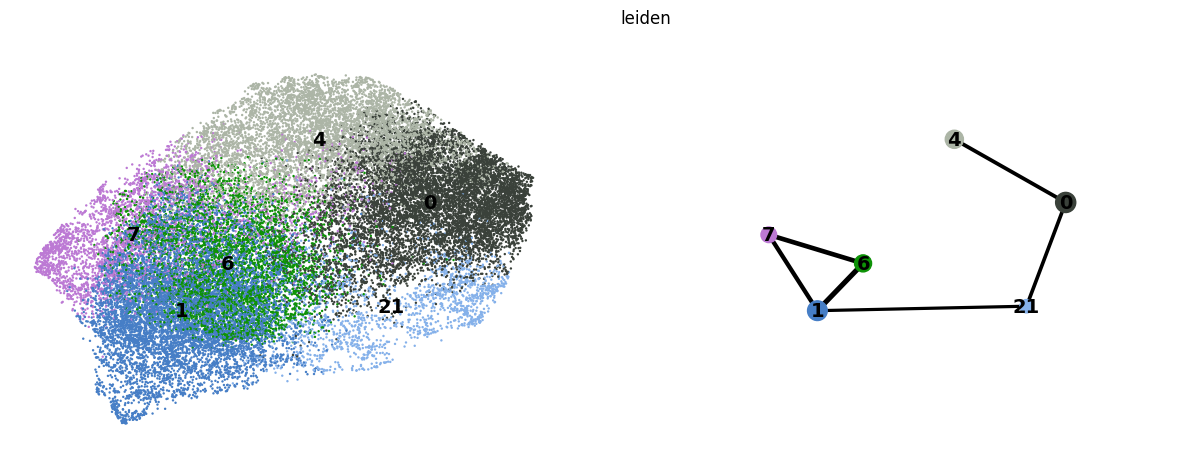

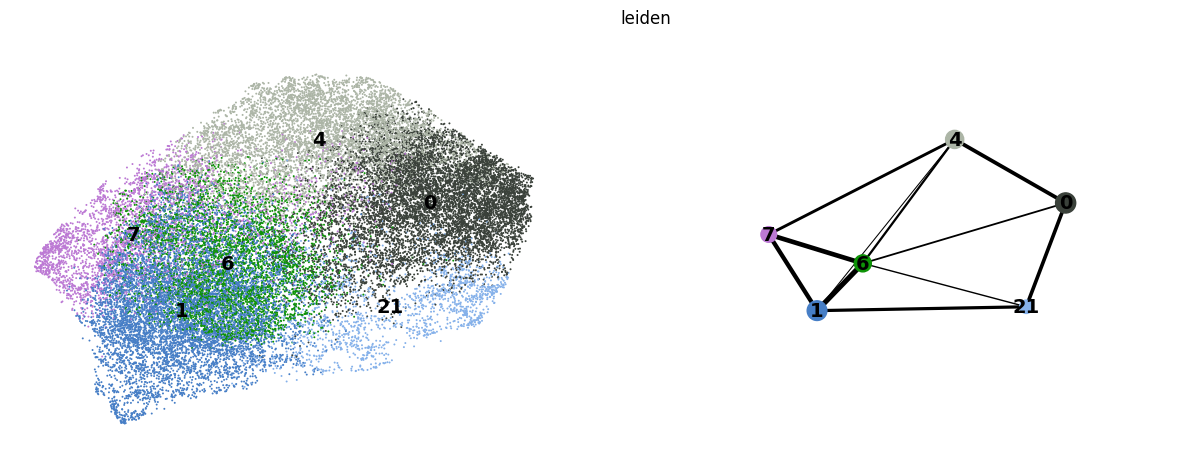

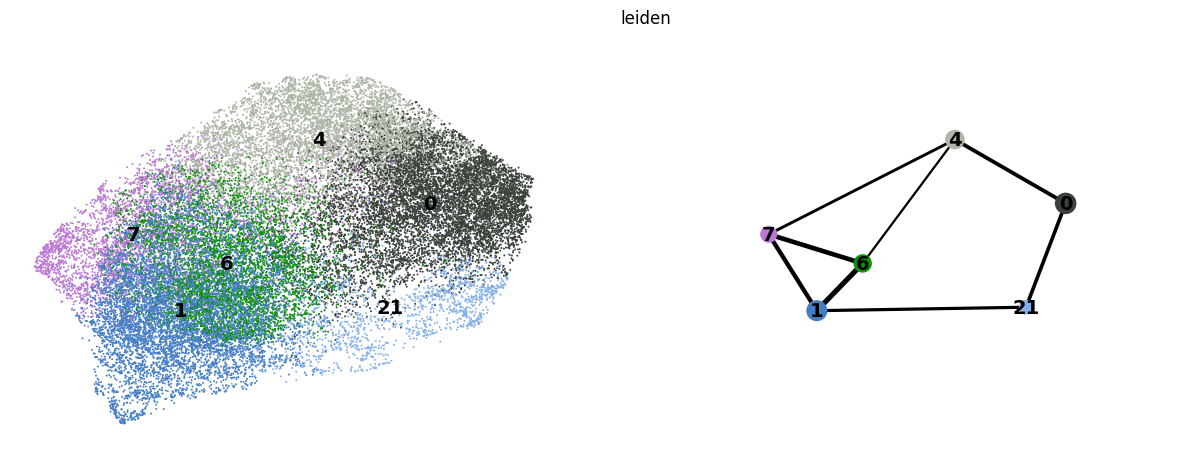

[<Axes: xlabel='FA1', ylabel='FA2'>, <Axes: >]

In [18]:
sc.tl.draw_graph(
    adata_paga,
    layout="fa",
    init_pos="paga",
    random_state=0,
)

sc.pl.paga_compare(
    adata_paga,
    basis="draw_graph_fa",
    color="leiden",
    threshold=threshold,
    frameon=False,
    legend_loc="on data",
    size=12,
    legend_fontsize=14
)

sc.tl.draw_graph(
    adata_paga,
    layout="fa",
    init_pos="paga",
    random_state=0,
)

sc.pl.paga_compare(
    adata_paga,
    basis="draw_graph_fa",
    color="leiden",
    threshold=0.1,
    frameon=False,
    legend_loc="on data",
    size=8,
    legend_fontsize=14
)
sc.tl.draw_graph(
    adata_paga,
    layout="fa",
    init_pos="paga",
    random_state=0,
)

sc.pl.paga_compare(
    adata_paga,
    basis="draw_graph_fa",
    color="leiden",
    threshold=0.2,
    frameon=False,
    legend_loc="on data",
    size=8,
    legend_fontsize=14
)